In [35]:
import csv
from pathlib import Path

import pandas as pd

# access data from the project-specific directory first
# if run from repo root => ./Projects/HoldingPenTime/Data
# if run from this notebook directory => ../Data
candidate_data_dirs = [
    Path.cwd() / 'Projects/HoldingPenTime/Data',
    Path.cwd().parent / 'Data',
]

dataDir = next((p.resolve() for p in candidate_data_dirs if p.exists()), candidate_data_dirs[0].resolve())
processed_directory = dataDir / 'processed'
processed_directory.mkdir(parents=True, exist_ok=True)


def detect_sep(path: Path) -> str:
    sample = path.read_text(encoding='utf-8', errors='ignore')[:4096]
    try:
        return csv.Sniffer().sniff(sample, delimiters=';,').delimiter
    except csv.Error:
        return ';'


def find_latest_by_prefix(base_dir: Path, prefixes: list[str]) -> Path:
    candidates = []
    for prefix in prefixes:
        candidates.extend(sorted(base_dir.glob(f'{prefix}*.csv')))
    if not candidates:
        raise FileNotFoundError(f'Could not find csv with prefixes {prefixes} in {base_dir}')
    return max(candidates, key=lambda p: p.stat().st_mtime)


# filter out relevant columns
cow_cols = ['Del_Cow_Id', 'FarmName_Pseudo', 'BreedName', 'BirthDate']
lactation_cols = ['Del_Cow_Id', 'FarmName_Pseudo', 'LactationInfoDate', 'LactationNumber', 'DaysInMilk']
traffic_cols = ['FarmName_Pseudo', 'GroupName', 'Del_Cow_Id', 'TrafficEventDateTime', 'PreviousArea', 'TimeInArea_totalSeconds', 'TrafficDeviceName', 'TrafficResult', 'MilkingInterval_totalSeconds']
robot_cols = ['FarmName_Pseudo', 'Del_Cow_Id', 'MilkingStartDateTime', 'SessionNumber', 'EquipmentName', 'TotalYield', 'MilkingUnitName']

cow_file = find_latest_by_prefix(dataDir, ['DF_Cow', 'gigacow'])
lactation_file = find_latest_by_prefix(dataDir, ['DF_Lactation', 'lactation'])
traffic_file = find_latest_by_prefix(dataDir, ['DF_Traffic', 'traffic'])
robot_file = find_latest_by_prefix(dataDir, ['DF_Robot', 'robot'])

print('Using files:')
print('robot full path:', robot_file)
print('cow      :', cow_file.name)
print('lactation:', lactation_file.name)
print('traffic  :', traffic_file.name)
print('robot    :', robot_file.name)

gigacow = pd.read_csv(cow_file, usecols=cow_cols, encoding='utf-8', sep=detect_sep(cow_file))
lactation = pd.read_csv(lactation_file, usecols=lactation_cols, encoding='utf-8', sep=detect_sep(lactation_file))
traffic_raw = pd.read_csv(traffic_file, usecols=traffic_cols, encoding='utf-8', sep=detect_sep(traffic_file))
robot = pd.read_csv(robot_file, usecols=robot_cols, encoding='utf-8', sep=detect_sep(robot_file))

# target farms
farm_list = ['f454e660', 'a624fb9a']

Using files:
robot full path: C:\projects\HoldingPenTime-v2-clean\Projects\HoldingPenTime\Data\DF_Robot_selected.csv
cow      : DF_Cow_selected.csv
lactation: DF_Lactation_selected.csv
traffic  : DF_Traffic_selected.csv
robot    : DF_Robot_selected.csv


In [36]:
#Directory path
dataDir = next((p.resolve() for p in candidate_data_dirs if p.exists()), candidate_data_dirs[0].resolve())

processed_subdirectory = 'processed'

# ull path for the 'processed' subdirectory
processed_directory = dataDir / processed_subdirectory

#Checks if the directory exists and creates it if it doesn't
if not processed_directory.exists():
    processed_directory.mkdir(parents=True, exist_ok=True)
    print(f"Directory '{processed_directory}' created.")
else:
    print(f"Directory '{processed_directory}' already exists.")

# Write data to file
gigacow.to_csv(processed_directory / 'gigacow_filter.csv')
gigacow

Directory 'C:\projects\HoldingPenTime-v2-clean\Projects\HoldingPenTime\Data\processed' already exists.


,Del_Cow_Id,FarmName_Pseudo,BreedName,BirthDate
0,350,a624fb9a,01 SRB,2023-05-14
1,487,f454e660,02 SLB,2019-09-17
2,866,a624fb9a,01 SRB,2020-09-21
3,892,f454e660,04 SJB,2020-07-30
4,912,a624fb9a,02 SLB,2020-07-07
...,...,...,...,...
75,37980,a624fb9a,01 SRB,2025-10-26
76,38938,a624fb9a,02 SLB,2025-11-12
77,39271,f454e660,02 SLB,2025-10-20
78,39382,a624fb9a,02 SLB,2025-12-27


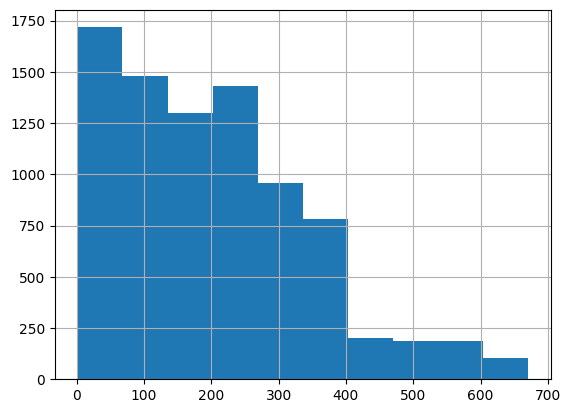

In [37]:
'''data table: lactation'''
#target farms: f454e660, a624fb9a
lactation = lactation.loc[lactation['FarmName_Pseudo'].isin(farm_list)]
#drop the farm name column
#lactation.drop('FarmName_Pseudo', axis=1, inplace=True)

#drop anomalies in DaysinMilk
#lactation = lactation.loc[lactation['DaysInMilk'] <= 330]

#Lactation Period
#plot the histogram of cows days in milk
lactation.dropna(subset=['DaysInMilk'], axis=0, inplace=True)
lactation.DaysInMilk.hist()
lactation.DaysInMilk.describe()

#test how the DelPro calculate DaysInMilk
#select specific cow and sort the records by the StartDate
test = lactation.loc[lactation['Del_Cow_Id'] == 1200]
test.sort_values(by='LactationInfoDate')

#merge table lactation and robot
#robot_lactation = robot.merge(lactation, how='left', on='Del_Cow_Id')
lactation.to_csv(dataDir/'processed/lactation_filter.csv')

In [38]:
lactation.DaysInMilk.describe()

count    8340.000000
mean      202.382854
std       143.273806
min         1.000000
25%        82.750000
50%       185.000000
75%       289.000000
max       671.000000
Name: DaysInMilk, dtype: float64

In [39]:
'''traffic raw table(contains all traffic events)'''

#target farms: f454e660, a624fb9a

#traffic_raw = pd.concat([traffic_f454e660_1, traffic_f454e660_2, traffic_a624fb9a])
traffic_raw.drop_duplicates(subset=['Del_Cow_Id', 'TrafficEventDateTime', 'PreviousArea'], keep='first', inplace=True)
#remove irrelevant traffic records, only keep Mjolkfalla,Mjölkfålla
#Unifiy PreviousArea name(vms1 & vms2)
traffic_raw['PreviousArea'].replace(r"(Mj)\w+", "Mjolkfalla", inplace=True, regex=True)
traffic_raw['TrafficResult'].replace("Mjölkfålla", "Mjolkfalla", inplace=True, regex=True)
#traffic_raw['PreviousArea'].replace(r"[Vv]*[Mm]+[Ss]+[^\S]*", "vms", inplace=True, regex=True)

#filter out irrelevant previous areas
previous_areas = ['Foderbord', 'Mjolkfalla', 'Koridor till Sorteringsgrind 2']
traffic_raw = traffic_raw.loc[traffic_raw['PreviousArea'].isin(previous_areas)]
traffic_raw.to_csv(dataDir/'processed/traffic_filter.csv', index=False)
traffic_raw

#Creates a subset of the traffic_raw DataFrame where the 'TrafficResult' column contains the string 'kg'
traffic_milk = traffic_raw[traffic_raw['TrafficResult'].astype(str).str.contains('kg', na=False)].copy()


In [40]:
#deprecated - used for analysis, comment this line if you want to reproduce the analysis experiment

'''data table: traffic_milking(only contain records for MilkingEvents)'''

#target farms: f454e660, a624fb9a
traffic_milk = traffic_milk.loc[traffic_milk['FarmName_Pseudo'].isin(farm_list)]
#drop the farm name column
traffic_milk.drop('FarmName_Pseudo', axis=1, inplace=True)
#Unifiy traffic device name(vms1 & vms2)
traffic_milk['TrafficDeviceName'].replace(r"[A-Za-z]+\s*","vms", inplace=True, regex=True)
#extract traffic result(milk production)
traffic_milk['TrafficResult'].replace(r"[^0-9.,]+"," ", inplace=True, regex=True)
traffic_milk['TrafficResult'].replace(r"\s*","", inplace=True, regex=True)
traffic_milk['TrafficResult'].replace(r"[,]+",".", inplace=True, regex=True)
traffic_milk['TrafficResult'] = traffic_milk['TrafficResult'].astype('float64')
traffic_milk.drop_duplicates(subset=['Del_Cow_Id', 'TrafficEventDateTime'], inplace=True)
traffic_milk.to_csv(dataDir/'processed/traffic_milk_filter.csv')
#print(traffic['TrafficResult'])
traffic_milk

,Del_Cow_Id,GroupName,TrafficEventDateTime,PreviousArea,TimeInArea_totalSeconds,TrafficDeviceName,TrafficResult,MilkingInterval_totalSeconds
21,13719,Vms kor (144 platser),2023-02-04 02:07:47,Mjolkfalla,600,vms2,8.33,23100.0
31,13719,Vms kor (144 platser),2023-07-17 11:31:23,Mjolkfalla,1020,vms1,15.80,23340.0
38,3711,Vms kor (144 platser),2022-03-18 12:43:54,Foderbord,26340,vms2,4.44,26400.0
48,487,Vms kor (144 platser),2022-02-28 16:47:28,Mjolkfalla,240,vms2,9.90,22740.0
83,487,Vms kor (144 platser),2023-06-02 17:35:46,Mjolkfalla,1500,vms1,21.39,31800.0
...,...,...,...,...,...,...,...,...
562840,13856,VMS 1,2025-04-13 08:43:14,Mjolkfalla,840,vms1,13.21,42780.0
562902,6906,VMS 1,2026-01-16 01:14:33,Foderbord,1380,vms2,9.06,14880.0
562913,6906,VMS 1,2026-01-21 00:29:45,Foderbord,60,vms1,8.53,14400.0
562914,6906,VMS 1,2026-01-22 00:54:30,Foderbord,1440,vms2,9.40,15720.0


In [41]:
#deprecated - used for analysis, comment this line if you want to reproduce the analysis experiment

'''data table: robot'''

#target farms: f454e660, a624fb9a
robot = robot.loc[robot['FarmName_Pseudo'].isin(farm_list)]
#drop the farm name column
#robot.drop('FarmName_Pseudo', axis=1, inplace=True)
#Unifiy robot equipment name(vms1 & vms2)
robot['EquipmentName'].replace(r"[A-Za-z]+\s*","vms", inplace=True, regex=True)
robot['MilkingUnitName'].replace(r"[A-Za-z]+\s*","vms", inplace=True, regex=True)

'''
    Q:check if equipmentName and milkingUnitName are exact same
    result:rows equipmentName and milkingUnitName are exact same
'''
#robot['EquipmentName'].equals(['MilkingUnitName'])
#robot['New'] = robot.apply(lambda x: x['EquipmentName'] if x['EquipmentName'] == x['MilkingUnitName'] else np.nan, axis=1)
#robot.to_csv('robot_filter.csv')
robot.drop('MilkingUnitName', axis=1, inplace=True)

#drop NA value in data table robot
robot.dropna(subset=['TotalYield'], axis=0, inplace=True)
robot.to_csv(dataDir/'processed/robot_filter.csv')
robot


,FarmName_Pseudo,Del_Cow_Id,MilkingStartDateTime,SessionNumber,EquipmentName,TotalYield
0,a624fb9a,11787,2023-05-19 20:20:00,4.0,vms2,10.92
1,a624fb9a,11787,2023-05-19 07:05:00,1.0,vms2,6.88
2,a624fb9a,11787,2023-05-19 09:32:00,3.0,vms2,2.17
3,a624fb9a,11787,2023-05-19 08:08:00,2.0,vms1,0.38
5,a624fb9a,11787,2023-05-20 08:39:00,1.0,vms2,11.86
...,...,...,...,...,...,...
22920,a624fb9a,13856,2025-11-03 01:38:00,1.0,vms1,10.62
22923,a624fb9a,11787,2025-11-03 00:55:00,1.0,vms1,9.84
22924,a624fb9a,11787,2025-11-03 12:00:00,2.0,vms1,14.09
22926,a624fb9a,11787,2025-11-03 21:50:00,3.0,vms1,11.13
